# Binary Classification Breakoutroom

### Permasalahan

> Churn adalah salah satu peristiwa atau perilaku pelanggan beralih dari produk setelah (dalam jangka waktu tertentu) berlangganan produk. Produk dapat berupa barang atau jasa, seperti jaringan internet, penyedia telekomunikasi, dan sejenisnya. Dalam hal ini produk yang dianalisa adalah perusahaan telekomunikasi. Skema churn dapat dijelaskan dalam beberapa tahap. Tahap pertama, tahap ketika pelanggan berlangganan produk. Tahap kedua, yaitu rutinitas, atau perilaku pelanggan atau umpan balik pelanggan terhadap produk yang digunakan selama periode tertentu. Setelah itu, pada tahap ketiga, ada dua jenis, retensi (berlangganan kembali) atau churn (beralih atau berhenti berlangganan). Setiap perusahaan pasti ingin meminimalkan churn dan memaksimalkan retensi. Salah satu solusi yang dapat digunakan adalah dengan menggunakan prediksi churn pelanggan. Dengan ini, perusahaan dapat mengetahui karakteristik yang cenderung beralih atau berhenti berlangganan.

### Deskripsi Data

1.   Gender: Jenis kelamin pelanggan (Male, Female)
2.   Partner: Status pernikahan pelanggan (yes, no)
3.   Tenure: Lama beralangganan (integer; bulan)
4.   PhoneService: Apakah pelanggan menggunakan telfon (yes, no)
5.   PaperlessBilling:  Apakah pelanggan menggunakan paperless billing (yes, no)
6.   MonthlyCharges: Biaya bulanan (numeric; usd)
7.   Churn: Apakah pelanggan berhenti berlangganan atau tidak (yes, no)

> Dalam kasus ini kita akan melakukan prediksi Churn sebagai variabel respon.




## 1. Import Libraries and Data

IMPORT PACKAGES

In [1]:
# connect colab ke g drive
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [25]:
# Import Package
import os
import pandas as pd
import numpy as np

# Package untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Package untuk cleaning, modelling, dan evaluation model
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [3]:
path = '/content/gdrive/MyDrive/PKKM KA/Day 2/Supervised/Dataset/'

In [4]:
os.listdir(path)

['house_prices.csv',
 'Data wine aroma.csv',
 'loan_prediction.csv',
 'TelcoChurn.csv']

IMPORT DATA

In [8]:
data = pd.read_csv(path+ "loan_prediction.csv")

## 2. Exploratory Data Analysis (EDA)

In [19]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [17]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [21]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [11]:
data.shape

(614, 13)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [20]:
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Married'].fillna(data['Married'].mode()[0], inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace=True)
data['Property_Area'].fillna(data['Property_Area'].mode()[0], inplace=True)
data['Loan_Status'].fillna(data['Loan_Status'].mode()[0], inplace=True)

data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)


data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0], inplace=True)

data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace=True)


<ipython-input-20-e02da05b1561>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
<ipython-input-20-e02da05b1561>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

## 3 Preprocessing

Label Encoder

In [22]:
kategori = ['Gender','Married','Education','Self_Employed','Dependents','Credit_History', 'Property_Area','Loan_Status']
df_cat = data[kategori]
df_cat.head()

,Gender,Married,Education,Self_Employed,Dependents,Credit_History,Property_Area,Loan_Status
0,Male,No,Graduate,No,0,1.0,Urban,Y
1,Male,Yes,Graduate,No,1,1.0,Rural,N
2,Male,Yes,Graduate,Yes,0,1.0,Urban,Y
3,Male,Yes,Not Graduate,No,0,1.0,Urban,Y
4,Male,No,Graduate,No,0,1.0,Urban,Y


In [23]:
df = data

In [26]:
# Ubah kedalam bentuk numerik
encoded_data = LabelEncoder()

for feature in kategori:
        if feature in df.columns.values:
            df[feature] = encoded_data.fit_transform(df[feature])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1,2,1


In [29]:
df.drop(columns=['Loan_ID'], inplace=True)

# 2. Memeriksa hasil setelah kolom dihapus
print("Dataset setelah menghapus kolom 'Loan_ID':")
print(df.head())

Dataset setelah menghapus kolom 'Loan_ID':
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0               1   
1             1508.0       128.0             360.0               1   
2                0.0        66.0             360.0               1   
3             2358.0       120.0             360.0               1   
4                0.0       141.0             360.0               1   

   Property_Area  Loan_Status  
0              2            1  
1        

Matrix Korelasi:
                     Gender   Married  Dependents  Education  Self_Employed  \
Gender             1.000000  0.364569    0.172914   0.045364      -0.000525   
Married            0.364569  1.000000    0.334216   0.012304       0.004489   
Dependents         0.172914  0.334216    1.000000   0.055752       0.056798   
Education          0.045364  0.012304    0.055752   1.000000      -0.010383   
Self_Employed     -0.000525  0.004489    0.056798  -0.010383       1.000000   
ApplicantIncome    0.058809  0.051708    0.118202  -0.140760       0.127180   
CoapplicantIncome  0.082912  0.075948    0.030430  -0.062290      -0.016100   
LoanAmount         0.106904  0.146546    0.163103  -0.168759       0.115100   
Loan_Amount_Term  -0.074030 -0.100912   -0.103864  -0.073928      -0.033739   
Credit_History     0.009170  0.010938   -0.040160  -0.073658      -0.001550   
Property_Area     -0.025752  0.004257   -0.000244  -0.065243      -0.030860   
Loan_Status        0.017987  0.0914

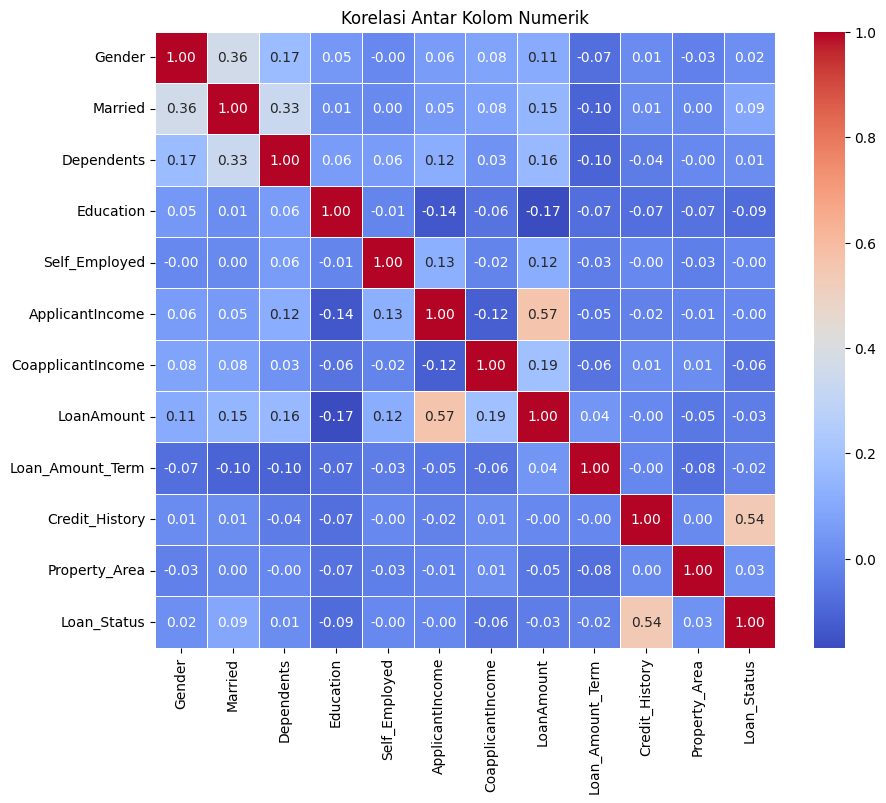

In [30]:
correlation_matrix = df.corr(method='pearson')

# 2. Menampilkan matrix korelasi
print("Matrix Korelasi:")
print(correlation_matrix)

# 3. Visualisasi Korelasi menggunakan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Kolom Numerik')
plt.show()

## 5. Membangun Model Klasifikasi

MEMBAGI TRAIN TEST DATA

In [31]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X Train : ", len(X_train))
print("y Train : ", len(y_train))
print("X Test : ", len(X_test))
print("t Test : ", len(y_test))

X Train :  429
y Train :  429
X Test :  185
t Test :  185


Menggunakan data testing berjumlah 30persen dari total data, dan data training berjumlah 70persen dari total data.

### Stats Model (Logistic Regression)

In [32]:
import statsmodels.api as sm

# 1. Menambahkan konstanta untuk intercept pada model
X_train_const = sm.add_constant(X_train)

# 2. Membuat model Logistik Regression dengan statsmodels
logreg_model_stats = sm.Logit(y_train, X_train_const)
result = logreg_model_stats.fit()

# 3. Menampilkan ringkasan model
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.453856
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Loan_Status   No. Observations:                  429
Model:                          Logit   Df Residuals:                      417
Method:                           MLE   Df Model:                           11
Date:                Thu, 14 Nov 2024   Pseudo R-squ.:                  0.2529
Time:                        06:23:33   Log-Likelihood:                -194.70
converged:                       True   LL-Null:                       -260.60
Covariance Type:            nonrobust   LLR p-value:                 7.523e-23
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.9162      0.923     -3.161      0.002      -4.724      -1.108
Gender  

Prediksi Model

In [33]:
# 1. Menambahkan konstanta untuk data uji (X_test)
X_test_const = sm.add_constant(X_test)

# 2. Melakukan prediksi pada data uji
y_pred_logreg = result.predict(X_test_const)

# 3. Mengubah probabilitas menjadi kelas (threshold 0.5 untuk klasifikasi)
y_pred_logreg_class = [1 if x >= 0.5 else 0 for x in y_pred_logreg]

# 4. Menampilkan hasil prediksi
print("Prediksi Kelas (0 = Tidak Churn, 1 = Churn):")
print(y_pred_logreg_class[:10])  # Menampilkan 10 prediksi pertama


Prediksi Kelas (0 = Tidak Churn, 1 = Churn):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### Evaluation Model

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Evaluasi model dengan mengukur akurasi
accuracy_logreg = accuracy_score(y_test, y_pred_logreg_class)

# 2. Evaluasi model dengan classification report (precision, recall, f1-score)
class_report_logreg = classification_report(y_test, y_pred_logreg_class)

# 3. Membuat confusion matrix
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg_class)

# 4. Menampilkan hasil evaluasi
print("Evaluasi Model Logistic Regression")
print(f"Akurasi: {accuracy_logreg}")
print("Classification Report:")
print(class_report_logreg)
print("Confusion Matrix:")
print(conf_matrix_logreg)


Evaluasi Model Logistic Regression
Akurasi: 0.7837837837837838
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

Confusion Matrix:
[[ 27  38]
 [  2 118]]


### SKLEARN (Logistic Regression)

In [35]:
from sklearn.svm import SVC

# 1. Membangun model SVM
svm_model = SVC()

# 2. Melatih model SVM dengan data latih
svm_model.fit(X_train, y_train)

# 3. Melakukan prediksi pada data uji
y_pred_svm = svm_model.predict(X_test)

# 4. Menampilkan hasil prediksi
print("Prediksi Kelas (0 = Tidak Churn, 1 = Churn) dengan SVM:")
print(y_pred_svm[:10])  # Menampilkan 10 prediksi pertama


Prediksi Kelas (0 = Tidak Churn, 1 = Churn) dengan SVM:
[1 1 1 1 1 1 1 1 1 1]


## Klasifikasi dengan SVM

In [36]:
# 1. Evaluasi model dengan mengukur akurasi
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# 2. Evaluasi model dengan classification report (precision, recall, f1-score)
class_report_svm = classification_report(y_test, y_pred_svm)

# 3. Membuat confusion matrix untuk SVM
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# 4. Menampilkan hasil evaluasi
print("Evaluasi Model Support Vector Machine (SVM)")
print(f"Akurasi: {accuracy_svm}")
print("Classification Report:")
print(class_report_svm)
print("Confusion Matrix:")
print(conf_matrix_svm)


Evaluasi Model Support Vector Machine (SVM)
Akurasi: 0.6486486486486487
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.65      1.00      0.79       120

    accuracy                           0.65       185
   macro avg       0.32      0.50      0.39       185
weighted avg       0.42      0.65      0.51       185

Confusion Matrix:
[[  0  65]
 [  0 120]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
